In [1]:
import os
import random
import re
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from transformers import BertTokenizer, BertForSequenceClassification

c:\Users\raad\Desktop\GenAI-Virtual-Environment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_path = "./data/sentiment-analysis-dataset/train.csv"
test_path = "./data/sentiment-analysis-dataset/test.csv"

In [3]:
# read the dataset
df_train = pd.read_csv(train_path, encoding="Windows-1252")
df_train.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
df_train = df_train[["text", "polarity"]]

# read the dataset
df_test = pd.read_csv(test_path, encoding="Windows-1252")
df_test.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
df_test = df_test[["text", "polarity"]]

# convert target variables into pytorch tensors
label_map = {"negative": 0, "neutral":1, "positive": 2}

df_train["polarity"] = df_train["polarity"].map(label_map)
df_test["polarity"] = df_test["polarity"].map(label_map)

df_test.head()

,text,polarity
0,Last session of the day http://twitpic.com/67ezh,1.0
1,Shanghai is also really exciting (precisely -...,2.0
2,"Recession hit Veronique Branquinho, she has to...",0.0
3,happy bday!,2.0
4,http://twitpic.com/4w75p - I like it!!,2.0


In [4]:
before = len(df_train)
df_train.dropna(how="any", inplace=True)
print(f"{before - len(df_train)} NaN rows dropped.")

1 NaN rows dropped.


In [5]:
before = len(df_test)
df_test.dropna(how="any", inplace=True)
print(f"{before - len(df_test)} NaN rows dropped.")
df_test['polarity'] = df_test['polarity'].astype('int')

1281 NaN rows dropped.


In [6]:

def text_preprocess(text):
    # Check if the text is a string
    if not isinstance(text, str):
        raise ValueError("Should be a str")

    # Remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    return text

# Just to not change the proprocessing for now
def text_preprocess(text):
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"#\w+", "", text)  # remove hashtags
    text = re.sub(r"@\w+", "", text)  # remove mentions
    # text = re.sub(r"[^\w\s]", "", text)  # remove special characters
    text = re.sub(r"[^\w\s,.!?'\":;()\-]", "", text)
    text = text.strip()  # remove extra whitespace

    return text

In [7]:
#apply the text_preprocess to
df_train["text_preprocessed"] = df_train["text"].apply(text_preprocess)
df_test["text_preprocessed"] = df_test["text"].apply(text_preprocess)

In [8]:
before = len(df_train)
df_train.drop_duplicates(subset=["text", "polarity"], inplace=True)
print(f"{before - len(df_train)} rows are dropped")
print(f"dataset has {len(df_train)} rows")

0 rows are dropped
dataset has 27480 rows


In [9]:
before = len(df_test)
df_test.drop_duplicates(subset=["text", "polarity"], inplace=True)
print(f"{before - len(df_test)} rows are dropped")
print(f"dataset has {len(df_test)} rows")

0 rows are dropped
dataset has 3534 rows


In [10]:
def is_garbled(text, threshold=0.5):
    non_alpha_ratio = len(re.findall(r'[^a-zA-Z\s]', text)) / max(len(text), 1)
    return non_alpha_ratio > threshold

In [11]:
before = len(df_train)
df_train = df_train[~df_train["text"].apply(is_garbled)]
print(f"{before - len(df_train)} rows are dropped")
print(f"dataset has {len(df_train)} rows")

18 rows are dropped
dataset has 27462 rows


In [12]:
before = len(df_test)
df_test = df_test[~df_test["text"].apply(is_garbled)]
print(f"{before - len(df_test)} rows are dropped")
print(f"dataset has {len(df_test)} rows")

1 rows are dropped
dataset has 3533 rows


In [13]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3, ignore_mismatched_sizes=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
for param in model.parameters():
    param.requires_grad = False

for layer in model.bert.encoder.layer[-6:]:
    for param in layer.output.parameters():
        param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

In [18]:
# Print trainable params summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params} / {total_params} ({100 * trainable_params/total_params:.2f}%)")

Trainable params: 14171907 / 109484547 (12.94%)


In [19]:
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }


In [20]:
# Set maximum sequence length
MAX_LEN = 64

In [21]:
# Create DataLoaders for train and val sets
train_dataset = CustomDataset(df_train['text_preprocessed'], df_train['polarity'], tokenizer, MAX_LEN)
test_dataset = CustomDataset(df_test['text_preprocessed'], df_test['polarity'], tokenizer, MAX_LEN)

In [22]:
# Define training parameters
batch_size = 16
epochs = 10
lr = 2e-5
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [23]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [24]:
# Training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [25]:
def compute_metrics_from_preds(labels, preds):
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

In [26]:
num_epochs = 30  # Number of epochs
losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0
max_patience = 5  # Maximum epochs to wait for improvement


for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    total_val_loss = 0

    # Training
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Training]", leave=True)

    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        avg_train_loss = total_train_loss / (train_loop.n + 1)

        # Update the postfix to show the current average training loss
        train_loop.set_postfix(train_loss=avg_train_loss)

    losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(test_loader)

    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")
    
    # Check if the current validation loss is the lowest; if so, save the model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pth')  # Save the best model
        patience = 0
    else:
        patience += 1
    
    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

Epoch 1/10 [Training]: 100%|██████████| 1717/1717 [00:34<00:00, 49.86it/s, train_loss=0.707]


Epoch 1/10, Training Loss: 0.7066, Validation Loss: 0.5633


Epoch 2/10 [Training]: 100%|██████████| 1717/1717 [00:34<00:00, 49.96it/s, train_loss=0.561]


Epoch 2/10, Training Loss: 0.5614, Validation Loss: 0.5576


Epoch 3/10 [Training]: 100%|██████████| 1717/1717 [00:34<00:00, 50.04it/s, train_loss=0.522]


...

Epoch 8/10, Training Loss: 0.3703, Validation Loss: 0.5882


Epoch 9/10 [Training]: 100%|██████████| 1717/1717 [00:34<00:00, 50.35it/s, train_loss=0.34] 


Epoch 9/10, Training Loss: 0.3398, Validation Loss: 0.6149


Epoch 10/10 [Training]: 100%|██████████| 1717/1717 [00:34<00:00, 50.28it/s, train_loss=0.305]


Epoch 10/10, Training Loss: 0.3053, Validation Loss: 0.6542
Early stopped at 10
Lowest Validation Loss: 0.5292 at Epoch 5


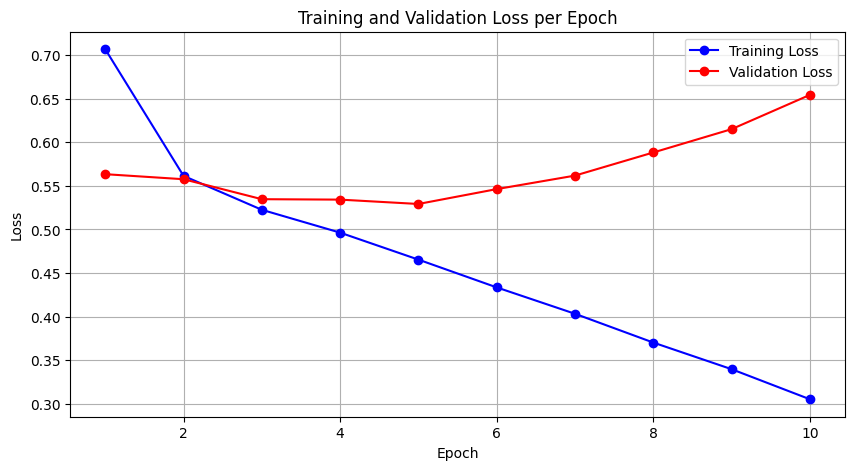

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [32]:
# Load saved weights
best_model_path = "best_model.pth"
model.load_state_dict(torch.load(best_model_path))
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [33]:
import torch.nn.functional as F


model.eval()
all_preds = []
all_labels = []
all_proba = [] # List to store probabilities

val_loss = 0.0
val_steps = 0

with torch.no_grad():
    val_iter = tqdm(test_loader, leave=True)
    for batch in val_iter:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        val_loss += loss.item()
        val_steps += 1

        # Get probabilities from logits using softmax
        probabilities = F.softmax(logits, dim=1)
        all_proba.extend(probabilities.detach().cpu().numpy().tolist())

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        val_iter.set_postfix(val_loss=f"{(val_loss/val_steps):.4f}")

metrics = compute_metrics_from_preds(all_labels, all_preds)

100%|██████████| 221/221 [00:03<00:00, 67.37it/s, val_loss=0.5292]


In [34]:
metrics

{'accuracy': 0.7877158222473818,
 'precision': 0.7878337638169247,
 'recall': 0.7877158222473818,
 'f1': 0.787608754999995}

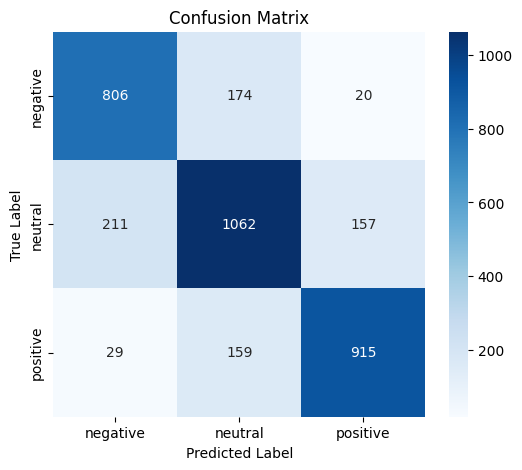

In [35]:
cm = confusion_matrix(all_labels, all_preds)
labels = ["negative", "neutral", "positive"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

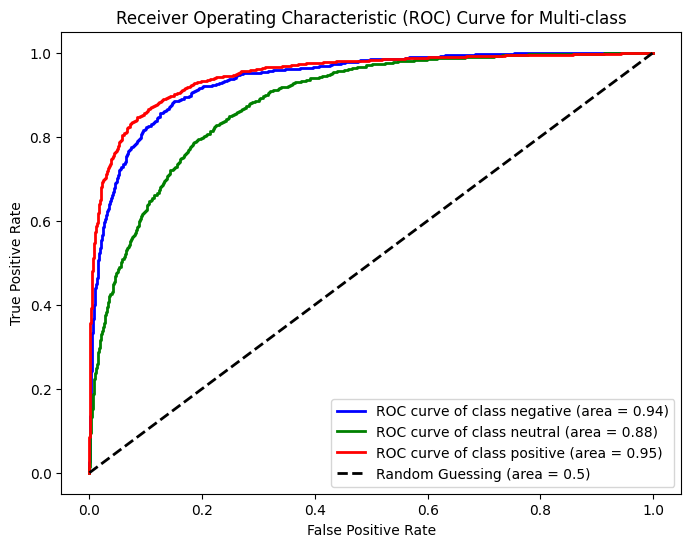

Macro-averaged One-vs-Rest ROC AUC score: 0.92


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Convert lists to numpy arrays
all_labels = np.array(all_labels)
all_proba = np.array(all_proba)

# Define the labels
labels = ["negative", "neutral", "positive"]
n_classes = len(labels)

# Binarize the true labels for the one-vs-rest strategy
y_true_bin = label_binarize(all_labels, classes=range(n_classes))

if not isinstance(y_true_bin, np.ndarray):
    y_true_bin = np.array(y_true_bin)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    # This slicing now works because y_true_bin and all_proba are numpy arrays
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red'] # Customize colors as needed

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (area = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")

# Calculate macro-averaged ROC AUC score (overall metric)
macro_roc_auc_ovr = roc_auc_score(all_labels, all_proba, multi_class="ovr", average="macro")
print(f"Macro-averaged One-vs-Rest ROC AUC score: {macro_roc_auc_ovr:.2f}")